## UPI TRANSACTIONS 2024 DATA ANALYTICS PROJECT

### Objective: The objective of this project is to analyze the UPI Transactions 2024 dataset using Python.The analysis focuses on identifying transaction trends,popular transaction types,merchant categories,transaction amounts,fraud patterns,and peak transaction hours.The goal is to generate meaningful insights and business recommendations that can help improve digital payment services and customer experience.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Load the dataset
df = pd.read_csv("/content/upi_transactions_2024.csv")
df

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,TXN0000249996,2024-11-08 22:41:43,Recharge,Food,373,SUCCESS,36-45,26-35,Telangana,ICICI,HDFC,iOS,5G,0,22,Friday,0
249996,TXN0000249997,2024-12-15 02:58:03,P2P,Utilities,2025,SUCCESS,36-45,26-35,Rajasthan,HDFC,Yes Bank,Android,5G,0,2,Sunday,1
249997,TXN0000249998,2024-11-27 16:33:25,P2P,Food,468,SUCCESS,26-35,18-25,West Bengal,ICICI,ICICI,Android,4G,0,16,Wednesday,0
249998,TXN0000249999,2024-01-05 13:31:30,Recharge,Healthcare,284,SUCCESS,18-25,36-45,Andhra Pradesh,Axis,ICICI,iOS,4G,0,13,Friday,0


In [3]:
df.head()

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   transaction id      250000 non-null  object
 1   timestamp           250000 non-null  object
 2   transaction type    250000 non-null  object
 3   merchant_category   250000 non-null  object
 4   amount (INR)        250000 non-null  int64 
 5   transaction_status  250000 non-null  object
 6   sender_age_group    250000 non-null  object
 7   receiver_age_group  250000 non-null  object
 8   sender_state        250000 non-null  object
 9   sender_bank         250000 non-null  object
 10  receiver_bank       250000 non-null  object
 11  device_type         250000 non-null  object
 12  network_type        250000 non-null  object
 13  fraud_flag          250000 non-null  int64 
 14  hour_of_day         250000 non-null  int64 
 15  day_of_week         250000 non-null  object
 16  is

In [5]:
df.shape

(250000, 17)

In [6]:
df.columns

Index(['transaction id', 'timestamp', 'transaction type', 'merchant_category',
       'amount (INR)', 'transaction_status', 'sender_age_group',
       'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank',
       'device_type', 'network_type', 'fraud_flag', 'hour_of_day',
       'day_of_week', 'is_weekend'],
      dtype='object')

In [7]:
df.isnull().sum()

,0
transaction id,0
timestamp,0
transaction type,0
merchant_category,0
amount (INR),0
transaction_status,0
sender_age_group,0
receiver_age_group,0
sender_state,0
sender_bank,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [10]:
df["Date"] = df["timestamp"].dt.date
df["Month"] = df["timestamp"].dt.month_name()
df["Day"] = df["timestamp"].dt.day_name()
df["Hour"] = df["timestamp"].dt.hour

In [11]:
len(df)

250000

In [12]:
df["transaction_status"].value_counts()

,count
transaction_status,
SUCCESS,237624
FAILED,12376


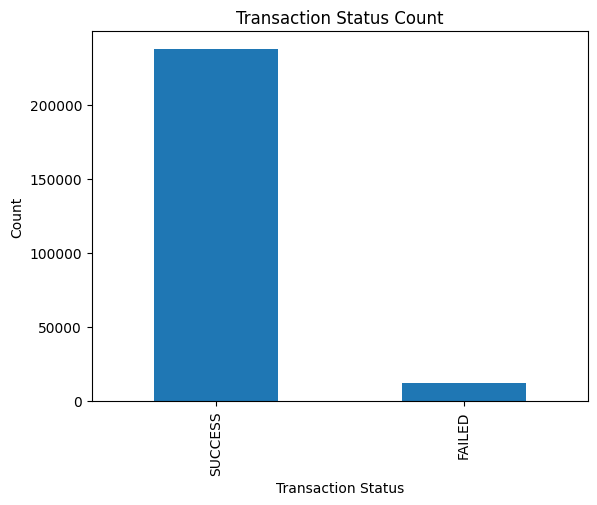

In [13]:
df["transaction_status"].value_counts().plot(kind="bar")
plt.xlabel("Transaction Status")
plt.ylabel("Count")
plt.title("Transaction Status Count")
plt.show()

#Transaction Status Analysis
## Insights:
#### . Most UPI transactions were successful,indicating a high success rate.
#### . Failed transactions were comparatively low,suggesting a reliable payment system.

## Business Interpretation:
#### Maintaining a high transaction success rate helps build customer trust and encourages continued use of digital payments.Payment providers should also analyze the reasons for failed transactions to further improve service quality and reduce failures.

In [14]:
df["transaction type"].value_counts()

,count
transaction type,
P2P,112445
P2M,87660
Bill Payment,37368
Recharge,12527


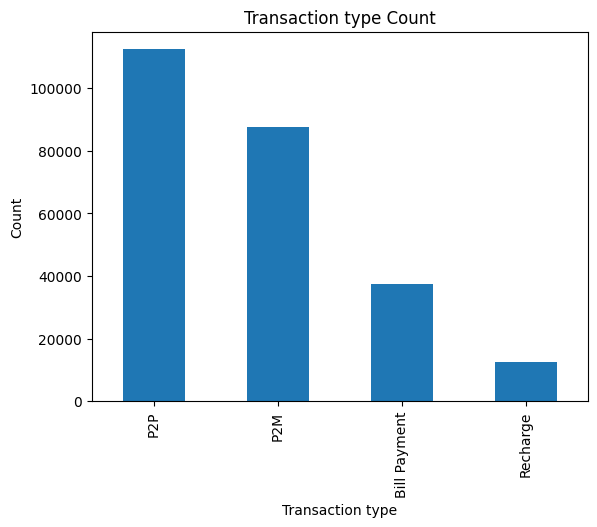

In [15]:
df["transaction type"].value_counts().plot(kind="bar")
plt.xlabel("Transaction type")
plt.ylabel("Count")
plt.title("Transaction type Count")
plt.show()

# Transaction type analysis
## Insights:
#### . P2P(Person-to-Person) transactions were the most common ,with 112,445 transactions,indicating that users frequently use UPI to transfer money between individuals.

#### . P2M(Person-to-Merchant) transactions were the second most common,with 87,660 transactions ,showing the UPI is also widely used for merchant payments.

#### . Bill payments accounted for 37,368 transactions,reflecting regular use of UPI for utility and service payments.

#### . Recharge had the lowest number of transactions (12,527),suggesting it is a less frequent use case compared to other transaction types.

## Business Interpretation:
#### UPI is primarily used for person-to-person transfers,while merchant payments are also a major use case.Banks and payment providers can focus on improving these services to enhance user experience.

In [16]:
df["merchant_category"].value_counts().head(10)

,count
merchant_category,
Grocery,49966
Food,37464
Shopping,29872
Fuel,25063
Other,24828
Utilities,22338
Transport,20105
Entertainment,20103
Healthcare,12663


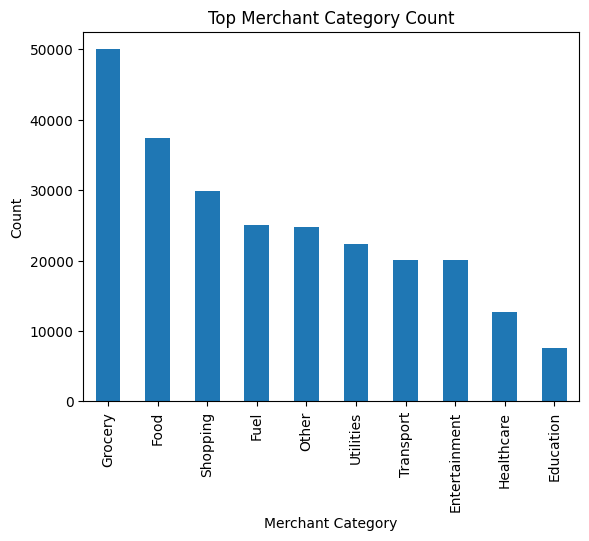

In [17]:
df["merchant_category"].value_counts().head(10).plot(kind="bar")
plt.xlabel("Merchant Category")
plt.ylabel("Count")
plt.title("Top Merchant Category Count")
plt.show()

# Merchant Category Analysis
## Insights:
#### . Grocery recorded the highest number of UPI transactions (49,966),indicating that users frequently rely on UPI for everyday essential purchases.

#### . Food(37,464) and Shopping(29,872) were the next most common categories,showing that UPI is widely used for dining and retail payments.

#### . Categories such as Healthcare(12,603)and Education(7,596)had comparatively fewer transactions,suggesting these payments occur less frequently than daily spending.

## Business Interpretation:
#### The analysis shows that UPI is primarily used for daily consumer spending,especially groceries,food,and shopping.Bussinesses in these categories should continue offering fast and secure UPI payment options,while sectors like healthcare and education have opportunities to encourage greater adoption of digital payments.

In [18]:
df["amount (INR)"].describe()

,amount (INR)
count,250000.000000
mean,1311.756036
std,1848.059224
min,10.000000
25%,288.000000
50%,629.000000
75%,1596.000000
max,42099.000000


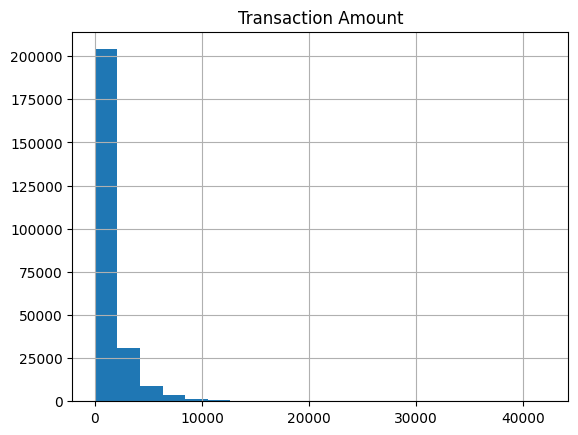

In [19]:
df["amount (INR)"].hist(bins=20)
plt.title("Transaction Amount")
plt.show()

# Transaction amount analysis
## Insights:
#### . The dataset contains 250,000 UPI transactions.
#### . The average transaction amount was approximately ₹1,311.76,indicating that most transactions are of moderate value.
#### . The minimum transaction amount was ₹10,while the maximum transaction amount reached ₹42,099,showing a wide range of transaction values.
#### . Since the median (₹629) is much lower than the mean (₹1,311.76),the dataset likely contains a few high-value transactions that increase the average.

## Business Interpretation:
#### Most UPI transactions are small to medium in value,while a limited number of high-value transactions contribute to a higher average transaction amount.Payment providers can focus on monitoring high-value transactions for security while ensuring a smooth experience for everyday low-value payments.

In [20]:
df["sender_state"].value_counts().head(10)

,count
sender_state,
Maharashtra,37427
Uttar Pradesh,30125
Karnataka,29756
Tamil Nadu,25367
Delhi,24870
Telangana,22435
Gujarat,20061
Andhra Pradesh,20006
Rajasthan,19981


In [21]:
df["sender_bank"].value_counts().head(10)

,count
sender_bank,
SBI,62693
HDFC,37485
ICICI,29769
IndusInd,25173
Axis,25042
PNB,24946
Yes Bank,24860
Kotak,20032


In [22]:
df["receiver_bank"].value_counts().head(10)

,count
receiver_bank,
SBI,62378
HDFC,37651
ICICI,29944
IndusInd,25086
Yes Bank,25009
Axis,24992
PNB,24802
Kotak,20138


In [23]:
df["device_type"].value_counts()

,count
device_type,
Android,187777
iOS,49613
Web,12610


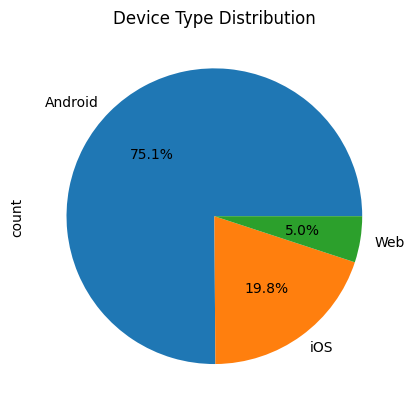

In [24]:
df["device_type"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.title("Device Type Distribution")
plt.show()

In [25]:
df["network_type"].value_counts()

,count
network_type,
4G,149813
5G,62582
WiFi,25134
3G,12471


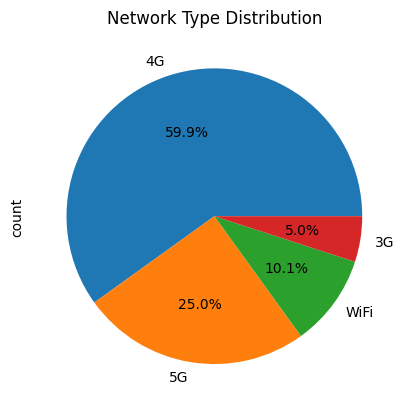

In [26]:
df["network_type"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.title("Network Type Distribution")
plt.show()

In [27]:
df["fraud_flag"].value_counts()

,count
fraud_flag,
0,249520
1,480


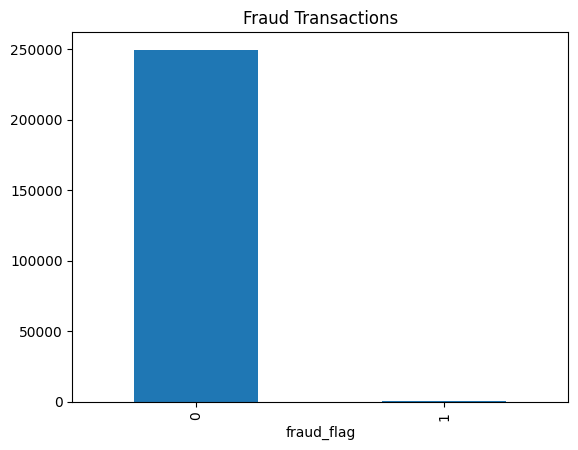

In [28]:
df["fraud_flag"].value_counts().plot(kind="bar")
plt.title("Fraud Transactions")
plt.show()

# Fraud analysis
## Insights:
#### . Out of 250,000 UPI transactions,249,520 were legitimate,while only 480 were identified as fraudulent.
#### . Fraudulent transactions account for a very small proportion of the total transactions,indicating that the majority of UPI transactions are secure and genuine.
#### . The low fraud rate suggests that digital payment systems have effective security measures in place.

## Business Interpretation:
#### The low number of fraudulent transactions helps maintain user trust in the UPI ecosystem.However,financial institutions should continue monitoring suspicious activities and strengthen fraud detection systems to prevent potential financial losses.

In [29]:
df["hour_of_day"].value_counts().sort_index()

,count
hour_of_day,
0,3388
1,2244
2,1685
3,1314
4,1247
5,1742
6,3501
7,5630
8,8349


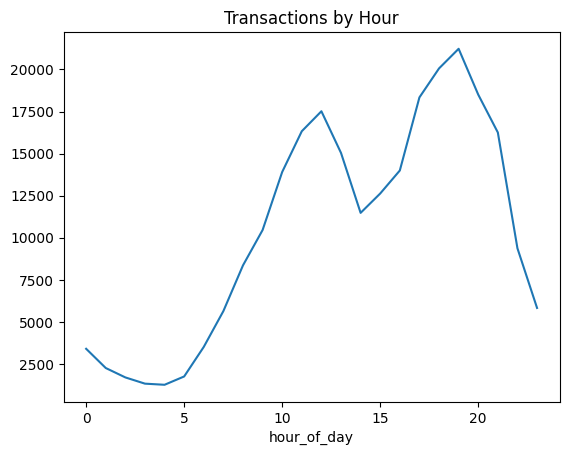

In [30]:
df["hour_of_day"].value_counts().sort_index().plot(kind="line")
plt.title("Transactions by Hour")
plt.show()

# Hour of Day analysis
## Insights:
#### . Transaction activity was lowest during the early morning hours(1 AM-5 AM),indicating limited user activity during the night.
#### . The number of transactions gradually increased from 6 AM onwards as people began their daily activities.
#### . Peak transaction activity occurred during the evening hours,with the highest number of transactions at 7 PM (21,232 transactions).
#### . After 8 PM , transaction volume gradually decreased as the day ended.

## Business Interpretation:
#### UPI transaction activity is highest during the evening ,likely due to shopping ,dining,bill payments,and personal money transfers after work.Payment service providers should ensure adequate server capacity and system performance during these peak hours to provide a smooth user experience.

In [32]:
df["is_weekend"].value_counts()

,count
is_weekend,
0,178663
1,71337


# Key Findings
#### . The dataset contains 250,000 UPI transactions, providing a comprehensive overview of digital payment activity.
#### . The majority of transactions were successful, indicating a reliable and efficient UPI payment system.
#### . P2P (Person-to-Person) transactions were the most common transaction type, followed by P2M (Person-to-Merchant) transactions.
#### . Grocery was the leading merchant category, followed by Food and Shopping, highlighting frequent use of UPI for everyday expenses.
#### . The average transaction amount was approximately ₹1,311.76, with transaction values ranging from ₹10 to ₹42,099.
#### . Only 480 out of 250,000 transactions were marked as fraudulent, indicating a very low fraud rate.
#### . Transaction activity peaked during the evening hours, with the highest number of transactions recorded around 7 PM.

# Business Recommendations
#### . Continue maintaining a high transaction success rate to enhance customer trust and satisfaction.
#### . Strengthen fraud detection and monitoring systems, particularly for high-value transactions.
#### . Ensure sufficient server capacity and system performance during evening peak hours to avoid delays.
#### . Focus on improving payment services for high-demand merchant categories such as Grocery, Food, and Shopping.
#### . Encourage greater adoption of digital payments in categories with lower transaction volumes, such as Education and Healthcare, through awareness programs and promotional offers.

# Conclusion
#### This project analyzed the UPI Transactions 2024 dataset using Python, Pandas, Matplotlib, and Google Colab. The analysis identified important transaction patterns, user payment behavior, merchant preferences, fraud occurrences, and peak transaction hours. The results showed that UPI is widely used for daily financial activities, with a high transaction success rate and a very low fraud rate. The insights and recommendations from this analysis can help banks, payment service providers, and businesses improve digital payment services, enhance security, and deliver a better customer experience.